<a href="https://colab.research.google.com/github/millenium0422471/Lab-Assignment/blob/main/Lesson_6_ml_basic_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=# California Housing Price Prediction

**Lesson 6 Machine Learning Basic Assignment**  
**Name:** Pius Nnaji

## Problem Definition

This project predicts median house value using the California Housing dataset.

This is a regression problem because the target variable, MedHouseVal, is continuous.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

=## Data Loading


In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Quick Check of Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Feature and Target Explanation

The target variable is `MedHouseVal`, which represents the median house value.

This is a regression problem because the target is continuous.

All features in this dataset are numerical. There are no categorical features.

=## EDA and Data Preprocessing

In [7]:
# Check for missing values
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [9]:
# Check for missing values
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### Missing Values

The dataset does not contain missing values, so no missing value treatment is required.

## Data Visualization

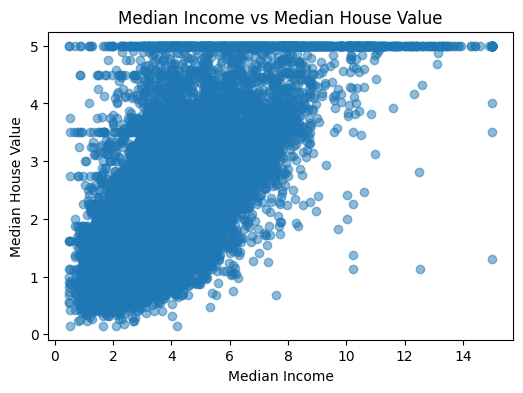

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

In [11]:
def plot_features_vs_target(data, target):
    features = data.drop(target, axis=1).columns

    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(data[feature], data[target], alpha=0.5)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
        plt.show()

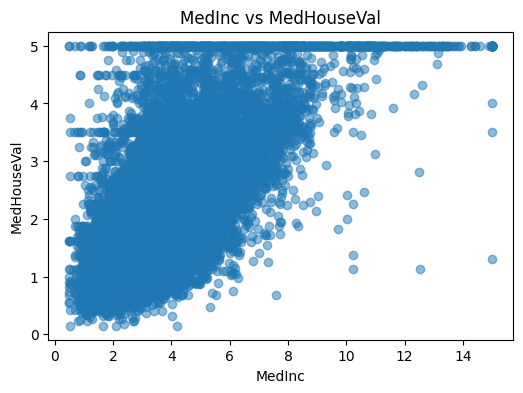

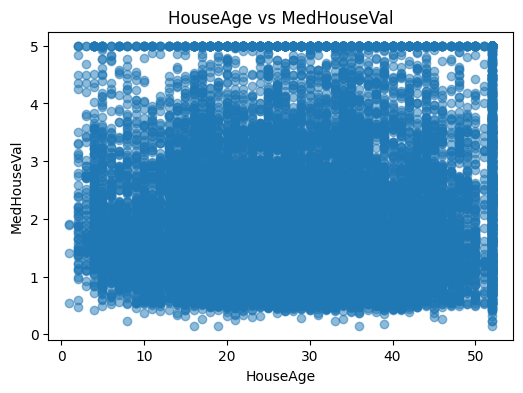

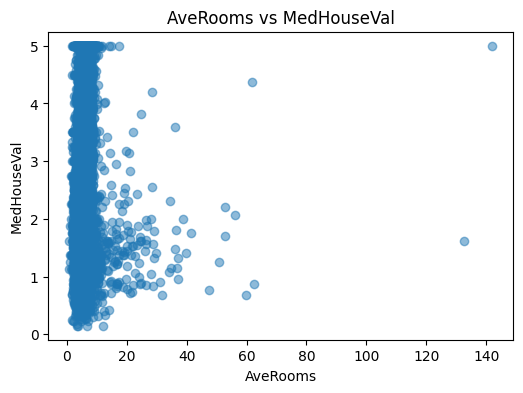

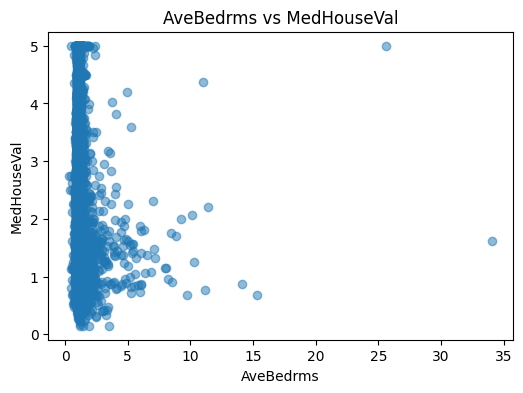

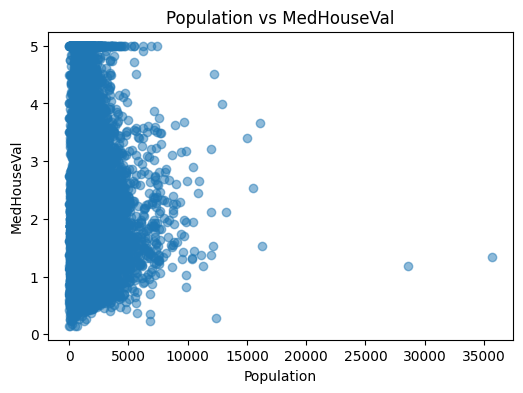

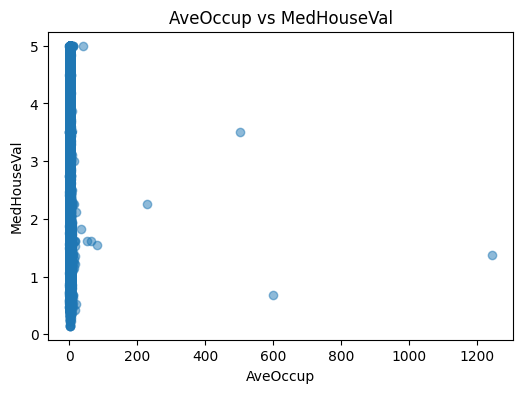

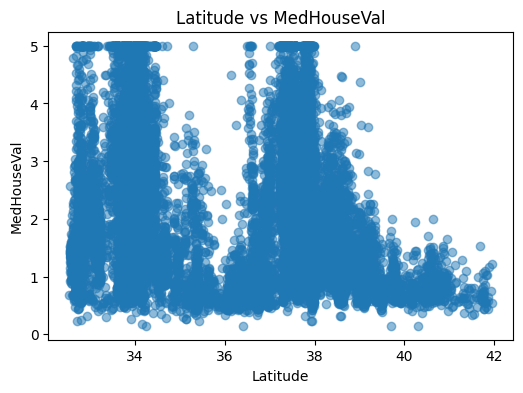

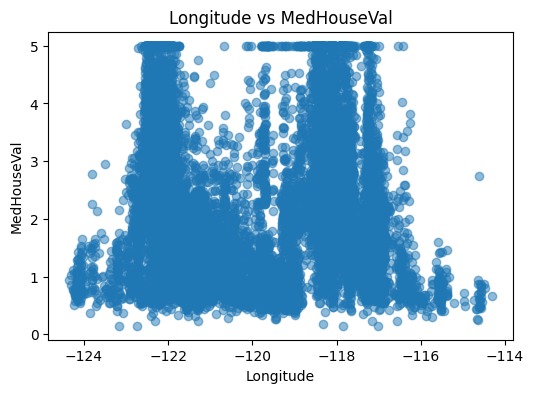

In [12]:
plot_features_vs_target(df, "MedHouseVal")

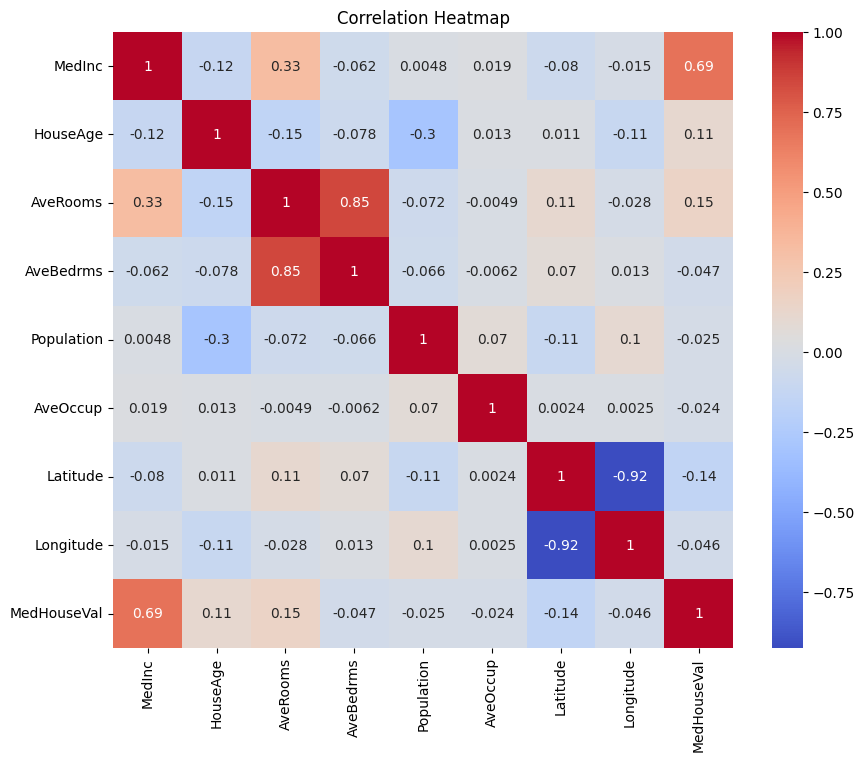

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Visualization Insight

Median income (`MedInc`) has a strong positive relationship with median house value (`MedHouseVal`). This means areas with higher median income usually have higher house values.

## Train-Test Split

In [14]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


## Model Training

In [15]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


=### Model Choice

Random Forest Regressor was selected because it works well for regression problems and can capture complex relationships between housing features and median house value.

## Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

In [16]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.5053
R² Score: 0.8051


### Evaluation Explanation

RMSE shows the average prediction error of the model.

R² shows how well the model explains the variation in median house values.

A higher R² score means better model performance.

## Model Prediction

In [17]:
new_data = pd.DataFrame([{
    "MedInc": 8.3252,
    "HouseAge": 41.0,
    "AveRooms": 6.9841,
    "AveBedrms": 1.0238,
    "Population": 322.0,
    "AveOccup": 2.5556,
    "Latitude": 37.88,
    "Longitude": -122.23
}])

prediction = model.predict(new_data)

print("Predicted Median House Value:", prediction[0])

Predicted Median House Value: 4.265793


## Conclusion

In this notebook, the California Housing dataset was used to build a regression model.

The data was explored using summary statistics, missing value checks, scatter plots, and a correlation heatmap.

A Random Forest Regressor was trained and evaluated using RMSE and R² score.

The model was also used to predict the median house value for a new set of input features.